# Torque(토크) 회귀 모델 비교

`ai4i2020.csv`의 `Torque [Nm]`을 나머지 센서·고장 컬럼으로 예측하는 회귀 문제를 4개 모델(Random Forest,
XGBoost, Linear Regression, SVR)로 학습하고 R²/MAE/RMSE/MAPE와 "실제값 vs 예측값" 산점도로 비교한다.

- 타겟: `Torque [Nm]` (3.8 ~ 76.6, 결측/0 없음)
- `classifications.ipynb`(Type 분류)와 짝을 이루는 회귀 버전. 참고: [`EDA.ipynb`](EDA.ipynb)

In [1]:
# 1. 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42

## 1. 데이터 로드 및 전처리

`classifications.ipynb`와 동일한 전처리(컬럼명/`Type`/`Product ID` 공백 strip).

In [2]:
# 2. 데이터 로드 + 공백 정리
df = pd.read_csv("ai4i2020.csv")
df.columns = [c.strip() for c in df.columns]
df["Type"] = df["Type"].str.strip()
df["Product ID"] = df["Product ID"].str.strip()

print("행/열 개수:", df.shape)
df.head()

행/열 개수: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. 특성(X)/타겟(y) 정의

타겟은 `Torque [Nm]`. **주의**: `Rotational speed`는 EDA에서 확인한 대로 `Torque`와 -0.88의 강한 상관관계가
있어 예측에 그대로 쓸 수 있지만, `Power`나 `Torque × Tool wear` 같이 `Torque`를 직접 곱해서 만든 파생변수는
타겟 정보를 그대로 포함하므로(데이터 누수) 특성에서 제외해야 한다 — 이 노트북에서는 애초에 그런 파생변수를
만들지 않는다.

In [3]:
# 3. 특성/타겟 분리
feature_cols = [
    "Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
    "Tool wear [min]", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF",
]
X = df[feature_cols].copy()
X.columns = [
    "Air_temperature", "Process_temperature", "Rotational_speed",
    "Tool_wear", "Machine_failure", "TWF", "HDF", "PWF", "OSF", "RNF",
]
y = df["Torque [Nm]"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "test:", X_test.shape)

train: (8000, 10) test: (2000, 10)


## 3. 스케일링

Linear Regression과 SVR은 스케일에 민감해 표준화한 데이터를, Random Forest·XGBoost는 원본 데이터를 쓴다
(분류 노트북과 동일한 이유).

In [4]:
# 4. 표준화 (train에만 fit)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. 모델 4개 정의 및 학습

In [5]:
# 5. 모델 정의: (모델 객체, 학습에 쓸 X_train, 테스트에 쓸 X_test)
models = {
    "Random Forest": (
        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
        X_train, X_test,
    ),
    "XGBoost": (
        XGBRegressor(n_estimators=300, random_state=RANDOM_STATE),
        X_train, X_test,
    ),
    "Linear Regression": (
        LinearRegression(),
        X_train_scaled, X_test_scaled,
    ),
    "SVR": (
        SVR(kernel="rbf"),
        X_train_scaled, X_test_scaled,
    ),
}

predictions = {}
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    predictions[name] = model.predict(X_te)
    print(f"{name} 학습 완료")

Random Forest 학습 완료


XGBoost 학습 완료
Linear Regression 학습 완료


SVR 학습 완료


## 5. 평가지표 — R² / MAE / RMSE / MAPE

In [6]:
# 6. 모델별 지표 계산
results = []
for name in models:
    y_pred = predictions[name]
    mse = mean_squared_error(y_test, y_pred)
    results.append({
        "모델": name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mse),
        "MAPE(%)": mean_absolute_percentage_error(y_test, y_pred) * 100,
    })

results_df = pd.DataFrame(results).set_index("모델").sort_values("R2", ascending=False)
results_df.round(3)

,R2,MAE,RMSE,MAPE(%)
모델,,,,
Random Forest,0.847,2.992,3.889,7.405
XGBoost,0.822,3.233,4.185,8.109
SVR,0.816,3.076,4.254,8.022
Linear Regression,0.804,3.424,4.400,9.373


## 6. 실제값 vs 예측값 산점도

모델 4개를 2x2로 배치해 실제 `Torque`와 예측값을 산점도로 비교한다. 대각선(y=x)에 가까울수록 예측이
정확하다는 뜻이다.

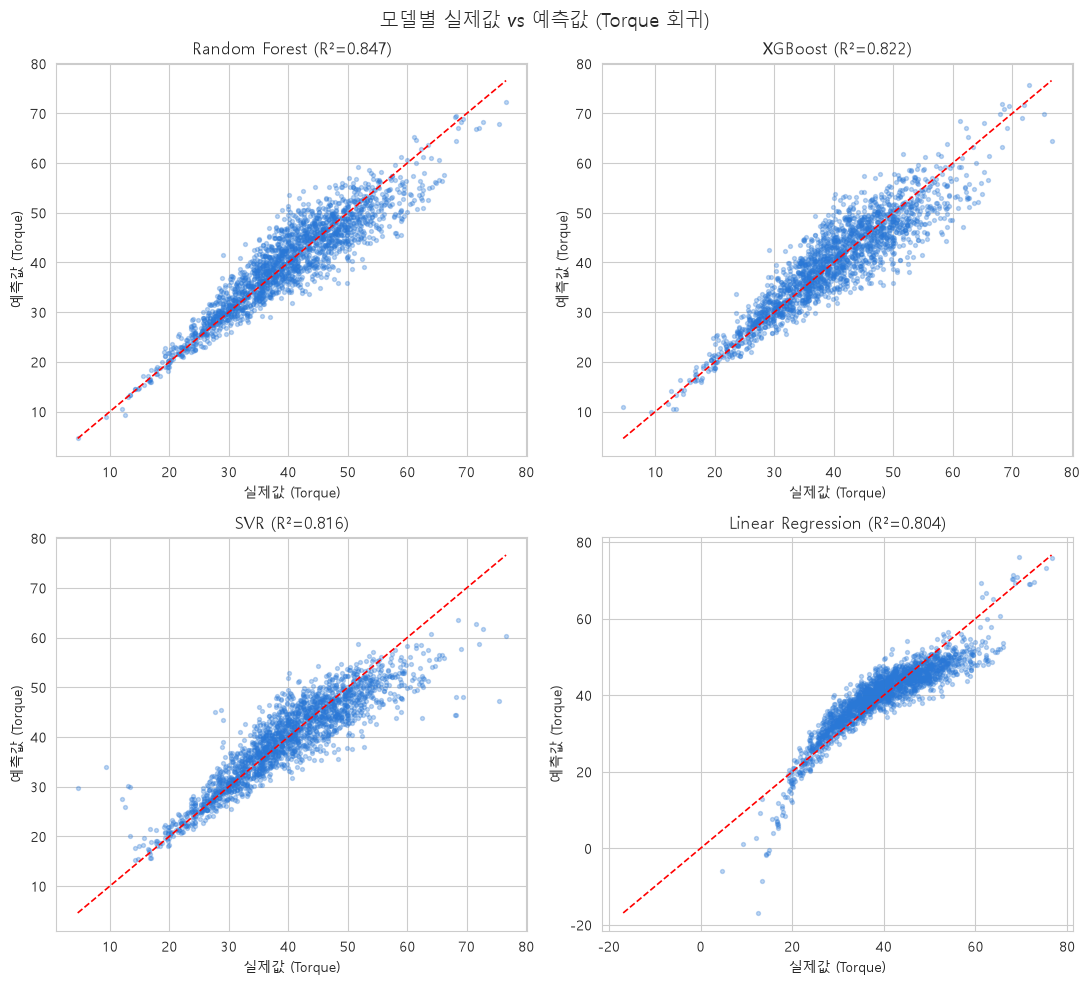

In [7]:
# 7. 실제값 vs 예측값 산점도 (2x2 서브플롯)
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, name in zip(axes.ravel(), results_df.index):  # R2 높은 순서로 배치
    y_pred = predictions[name]
    ax.scatter(y_test, y_pred, s=8, alpha=0.3, color="#2a78d6")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.2)  # y=x 기준선
    ax.set_title(f"{name} (R²={results_df.loc[name, 'R2']:.3f})")
    ax.set_xlabel("실제값 (Torque)")
    ax.set_ylabel("예측값 (Torque)")

fig.suptitle("모델별 실제값 vs 예측값 (Torque 회귀)", fontsize=14)
fig.tight_layout()
fig.savefig("../images/regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 결론

R² 기준 **Random Forest(0.847) > XGBoost(0.822) > SVR(0.816) > Linear Regression(0.804)** 순이었다.
MAE는 2.99~3.42 Nm, RMSE는 3.89~4.40 Nm 수준(Torque 표준편차가 약 9.97이므로 오차가 표준편차의
30~40% 정도), MAPE는 7.4~9.4%였다.

- Type 분류(`classifications.ipynb`, AUC 0.48~0.51 = 랜덤 수준)와 달리, **Torque 회귀는 4개 모델 모두
  R² 0.8 이상으로 뚜렷하게 예측이 된다.** EDA에서 확인한 `Rotational speed`↔`Torque`의 강한 음의
  상관관계(-0.88)가 그대로 회귀 모델의 예측력으로 이어진 것으로 해석된다 — 즉 이 데이터셋은 "물리적으로
  실제 관계가 있는 변수(Torque)는 잘 예측되고, 관계가 약한 라벨(Type)은 잘 예측되지 않는다"는 일관된
  패턴을 보인다.
- Random Forest가 가장 좋았지만 4개 모델 간 R² 차이가 0.04 이내로 크지 않다 — 비선형 트리 모델
  (RF/XGBoost)이 선형 모델(Linear Regression)보다 약간 낫지만, 이 데이터에서는 모델 종류보다 특성
  자체(회전속도)의 설명력이 더 중요하다는 뜻.
- `../images/regression_scatter.png`의 산점도에서도 4개 모델 모두 점들이 y=x 대각선 주변에 몰려있어
  같은 결론을 확인할 수 있다(Random Forest가 대각선에 가장 가까움).
- 실행: 저장소 루트에서 `jupyter nbconvert --to notebook --execute --inplace src/regression.ipynb`